In [11]:
import pandas as pd

In [13]:
from sklearn.datasets import load_iris

In [15]:
from sklearn.model_selection import train_test_split

In [17]:
from sklearn.preprocessing import StandardScaler

In [19]:
import warnings

In [21]:
warnings.filterwarnings("ignore")

In [23]:
iris_raw = load_iris()

In [25]:
X_iris = iris_raw.data

In [27]:
y_iris = iris_raw.target

In [29]:
scaler_iris = StandardScaler()

In [31]:
X_iris_scaled = scaler_iris.fit_transform(X_iris)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_iris_scaled, y_iris, test_size=0.20, stratify=y_iris, random_state=42)

In [35]:
print("Training set shape:", X_train.shape)

Training set shape: (120, 4)


In [37]:
print("Test set shape:", X_test.shape)

Test set shape: (30, 4)


In [39]:
##SUBTASK-1.2
from sklearn.linear_model import LogisticRegression

In [41]:
from sklearn.metrics import accuracy_score

In [43]:
lr_model= LogisticRegression(multi_class = 'multinomial', solver = 'lbfgs', random_state = 42)

In [45]:
lr_model.fit(X_train,y_train)

LogisticRegression(multi_class='multinomial', random_state=42)

In [49]:
lr_preds = lr_model.predict(X_test)

In [51]:
lr_accuracy = accuracy_score(y_test, lr_preds)

In [53]:
print(f"Logistic Regression Test Accuracy: {lr_accuracy * 100:.2f}%")

Logistic Regression Test Accuracy: 93.33%


In [57]:
##SUBTASK-1.3
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [59]:
lda_model = LinearDiscriminantAnalysis()

In [61]:
lda_model.fit(X_train,y_train)

LinearDiscriminantAnalysis()

In [63]:
lda_preds = lda_model.predict(X_test)

In [65]:
lda_accuracy = accuracy_score(y_test, lda_preds)

In [67]:
print(f"LDA Test Accuracy: {lda_accuracy * 100:.2f}%")

LDA Test Accuracy: 100.00%


In [69]:
##SUBTASK-1.4
from sklearn.neighbors import KNeighborsClassifier

In [73]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [75]:
knn = KNeighborsClassifier()

In [77]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [79]:
y_pred_knn = knn.predict(X_test)

In [85]:
knn_accuracy = accuracy_score(y_test,y_pred_knn)

In [87]:
print("k-NN Classification Accuracy:", knn_accuracy)

k-NN Classification Accuracy: 0.9333333333333333


In [91]:
##SUBTASK-1.5
comparison_df = pd.DataFrame({'Supervised Classifier':['Logistic Regression', 'Linear Discriminant Analysis (LDA)', 'k-Nearest Neighbors (k-NN)'],'Test Accuracy (%)':[lr_accuracy * 100, lda_accuracy * 100, knn_accuracy * 100]})

In [93]:
print("---{Performance Comparison on Iris Dataset---")

---{Performance Comparison on Iris Dataset---


In [95]:
print(comparison_df.to_string(index=False))

             Supervised Classifier  Test Accuracy (%)
               Logistic Regression          93.333333
Linear Discriminant Analysis (LDA)         100.000000
        k-Nearest Neighbors (k-NN)          93.333333


In [97]:
##TASK-2
##SUBTASK-2.1
import pandas as pd

In [99]:
from sklearn.model_selection import train_test_split

In [101]:
from sklearn.preprocessing import StandardScaler

In [103]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [105]:
sonar_features = [f"F_{i}" for i in range(1,61)]

In [107]:
sonar_columns = sonar_features + ['Class']

In [109]:
sonar_df = pd.read_csv(sonar_url, header=None, names = sonar_columns)

In [115]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1,'R' : 0})

In [117]:
X_sonar = sonar_df[sonar_features]

In [119]:
y_sonar = sonar_df['Class_numeric']

In [121]:
scaler_sonar = StandardScaler()

In [123]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [125]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sonar_scaled, y_sonar, test_size = 0.30, stratify = y_sonar,random_state = 42)

In [127]:
print("Sonar Training Set Shape:",X_train_s.shape)

Sonar Training Set Shape: (145, 60)


In [129]:
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Test Set Shape: (63, 60)


In [131]:
##SUBTASK-2.2
from sklearn.naive_bayes import GaussianNB

In [133]:
from sklearn.metrics import accuracy_score

In [135]:
nb_model = GaussianNB()

In [137]:
nb_model.fit(X_train_s, y_train_s)

GaussianNB()

In [139]:
nb_preds = nb_model.predict(X_test_s)

In [141]:
nb_accuracy = accuracy_score(y_test_s, nb_preds)

In [143]:
print(f"Gaussian Naive Bayes Test Accuracy: {nb_accuracy * 100:.2f}%")

Gaussian Naive Bayes Test Accuracy: 76.19%


In [145]:
##SUBTASK-2.3
from sklearn.svm import SVC

In [147]:
svm_linear = SVC(kernel = 'linear', probability=True, random_state=42)

In [149]:
svm_linear.fit(X_train_s, y_train_s)

SVC(kernel='linear', probability=True, random_state=42)

In [151]:
linear_preds = svm_linear.predict(X_test_s)

In [153]:
linear_accuracy = accuracy_score(y_test_s, linear_preds)

In [155]:
print(f"Linear Kernel SVM Test Accuracy: {linear_accuracy * 100:.2f}%")

Linear Kernel SVM Test Accuracy: 79.37%


In [159]:
sonar_comparison = pd.DataFrame({'Classifier': ['Gaussian Naive Bayes (Probabilistic)', 'Linear Kernel SVM (Maximum-Margin)'], 'Test Accuracy (%)': [nb_accuracy * 100, linear_accuracy *100]})

In [161]:
print("---Perfomance Comparison on High-Dimensional SonarDataset---")

---Perfomance Comparison on High-Dimensional SonarDataset---


In [163]:
print(sonar_comparison.to_string(index=False))

                          Classifier  Test Accuracy (%)
Gaussian Naive Bayes (Probabilistic)          76.190476
  Linear Kernel SVM (Maximum-Margin)          79.365079


In [165]:
##TASK-3
##SUBTASK-3.1
import matplotlib.pyplot as plt

In [167]:
import seaborn as sns 

In [169]:
from sklearn.metrics import confusion_matrix

In [171]:
cm = confusion_matrix(y_test, lr_preds)

In [173]:
plt.figure(figsize=(5,4))

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

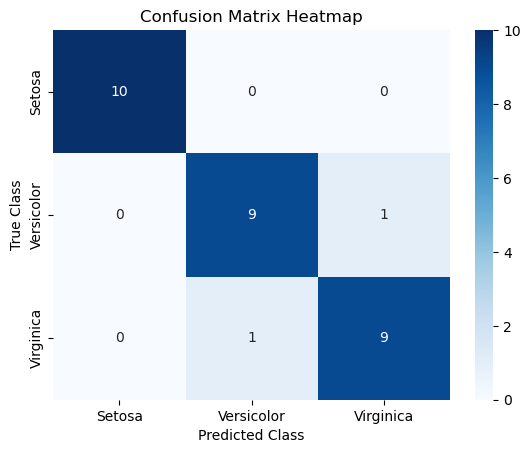

In [201]:
sns.heatmap(cm, annot=True,fmt='d', cmap='Blues', xticklabels=['Setosa', 'Versicolor', 'Virginica'], yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.title("Confusion Matrix Heatmap")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()           